# Grid Demand Forecast

Next-hour `demand_mw` prediction on PGCB hourly data, with weather and World Bank macro indicators as auxiliary features. Models: Ridge baseline, Random Forest, XGBoost, LightGBM. Final model is a tuned LightGBM. Chronological split: train < 2023, test = 2023.


## 1. Setup

In [42]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import lightgbm as lgb

DATA_DIR = Path("/content")
OUT_DIR = Path("/mnt/user-data/outputs")
SEED = 42

pd.set_option("display.max_columns", 50)
plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Load demand data

In [43]:
demand_raw = pd.read_excel(DATA_DIR / "PGCB_date_power_demand.xlsx")
demand_raw = demand_raw.sort_values("datetime").reset_index(drop=True)

print("shape:", demand_raw.shape)
print("range:", demand_raw["datetime"].min(), "->", demand_raw["datetime"].max())
demand_raw.head()


shape: (92650, 15)
range: 2015-04-19 00:00:00 -> 2025-06-17 12:00:00


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


In [44]:
demand_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal           

In [45]:
demand_raw["demand_mw"].describe([0.001, 0.01, 0.5, 0.99, 0.999])

,demand_mw
count,92650.000000
mean,8819.646044
std,2772.150108
min,6.000000
0.1%,3284.947000
1%,4166.490000
50%,8422.000000
99%,15150.000000
99.9%,16280.265000
max,156050.000000


## 3. Clean demand

In [46]:
df = demand_raw.copy()

hourly = df["datetime"].dt.minute == 0
print(f"dropping {(~hourly).sum():,} half-hour rows")
df = df[hourly].copy()

dups = df.duplicated("datetime").sum()
print(f"collapsing {dups:,} duplicate timestamps")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df.groupby("datetime", as_index=False)[num_cols].mean()


dropping 4,181 half-hour rows
collapsing 423 duplicate timestamps


In [47]:
demand_typo = df["demand_mw"] > 5 * df["generation_mw"].clip(lower=1)
print(f"demand typos (/10): {demand_typo.sum()}")
df.loc[demand_typo, "demand_mw"] /= 10

gen_typo = df["generation_mw"] > 50_000
print(f"generation typos (/10000): {gen_typo.sum()}")
df.loc[gen_typo, "generation_mw"] /= 10_000

tiny = df["demand_mw"] < 500
print(f"tiny -> NaN: {tiny.sum()}")
df.loc[tiny, "demand_mw"] = np.nan


demand typos (/10): 11
generation typos (/10000): 1
tiny -> NaN: 7


In [48]:
full_idx = pd.date_range(df["datetime"].min(), df["datetime"].max(), freq="h")
df = df.set_index("datetime").reindex(full_idx)
df.index.name = "datetime"

print(f"missing hours after reindex: {df['demand_mw'].isna().sum():,}")

df["demand_mw"]     = df["demand_mw"].interpolate(method="time", limit=6).ffill().bfill()
df["generation_mw"] = df["generation_mw"].interpolate(method="time", limit=6).ffill().bfill()

print(f"remaining NaNs in demand_mw: {df['demand_mw'].isna().sum()}")
df["demand_mw"].describe()


missing hours after reindex: 1,062
remaining NaNs in demand_mw: 0


,demand_mw
count,89101.000000
mean,8745.112786
std,2612.034641
min,556.000000
25%,6731.000000
50%,8349.000000
75%,10560.000000
max,20587.000000


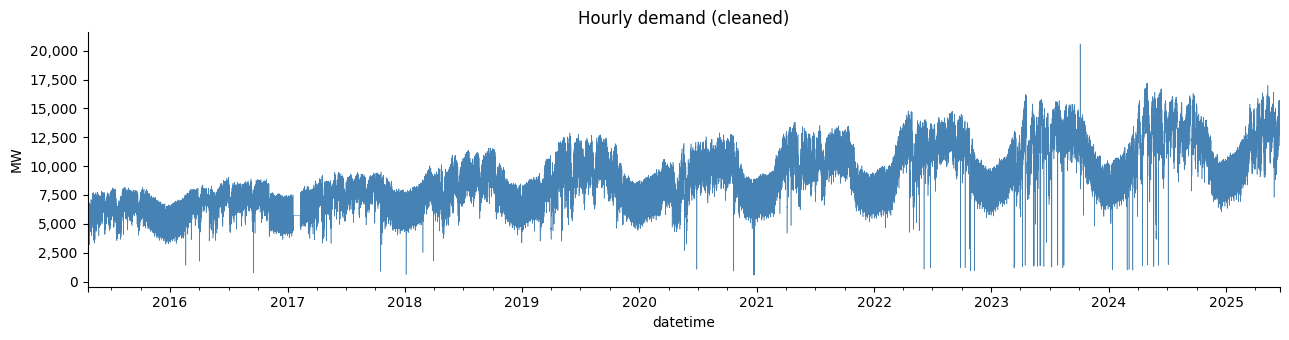

In [49]:
fig, ax = plt.subplots(figsize=(13, 3.5))
df["demand_mw"].plot(ax=ax, lw=0.4, color="steelblue")
ax.set_title("Hourly demand (cleaned)")
ax.set_ylabel("MW")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()


## 4. Weather

In [50]:
weather = pd.read_excel(
    DATA_DIR / "weather_data.xlsx",
    skiprows=3,
    names=["datetime", "temp_c", "humidity", "dew_point", "precip",
           "rain", "cloud_cover", "wind_speed", "wind_dir", "sunshine"],
)
weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce")
weather = (
    weather.dropna(subset=["datetime"])
           .set_index("datetime")
           .sort_index()
)
weather = weather[~weather.index.duplicated(keep="first")]

print("shape:", weather.shape)
print("range:", weather.index.min(), "->", weather.index.max())
print("total NaNs:", weather.isna().sum().sum())
weather.head()


shape: (107304, 9)
range: 2014-01-01 00:00:00 -> 2026-03-29 23:00:00
total NaNs: 0


,temp_c,humidity,dew_point,precip,rain,cloud_cover,wind_speed,wind_dir,sunshine
datetime,,,,,,,,,
2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


## 5. Economics

In [51]:
econ_raw = pd.read_csv(DATA_DIR / "economic_full_1.csv")
print("indicators available:", econ_raw["Indicator Name"].nunique())

chosen = {
    "GDP (current US$)":                                         "gdp_usd",
    "GDP growth (annual %)":                                     "gdp_growth",
    "GDP per capita (current US$)":                              "gdp_per_capita",
    "Population, total":                                         "population",
    "Urban population":                                          "urban_population",
    "Urban population (% of total population)":                  "urban_pop_pct",
    "Industry (including construction), value added (% of GDP)": "industry_pct_gdp",
    "Manufacturing, value added (% of GDP)":                     "manufacturing_pct_gdp",
    "Access to electricity (% of population)":                   "electricity_access_pct",
    "Electric power consumption (kWh per capita)":               "elec_consumption_per_cap",
}

year_cols = [str(y) for y in range(2014, 2026)]
econ_long = (
    econ_raw[econ_raw["Indicator Name"].isin(chosen)]
    .melt(id_vars=["Indicator Name"], value_vars=year_cols, var_name="year", value_name="value")
)
econ_long["year"] = econ_long["year"].astype(int)
econ_long["ind"]  = econ_long["Indicator Name"].map(chosen)

econ = econ_long.pivot_table(index="year", columns="ind", values="value").ffill()
econ


indicators available: 1516


ind,elec_consumption_per_cap,electricity_access_pct,gdp_growth,gdp_per_capita,gdp_usd,industry_pct_gdp,manufacturing_pct_gdp,population,urban_pop_pct,urban_population
year,,,,,,,,,,
2014,326.502853,62.4,6.061059,1094.461997,1.728870e+11,26.311047,16.612708,157964929.0,29.194444,46116983.0
2015,348.932681,74.0,6.552640,1224.386477,1.951470e+11,26.831395,16.788674,159383179.0,29.539510,47081010.0
2016,412.780315,75.9,7.113478,1649.283809,2.652250e+11,31.069151,20.347948,160811932.0,29.875392,48043194.0
2017,443.212946,88.0,6.590250,1811.082217,2.937320e+11,31.248292,20.075062,162186147.0,30.201580,48982779.0
2018,471.126089,86.9,7.319413,1965.243727,3.213630e+11,31.982814,20.802296,163523103.0,30.517566,49903270.0
2019,515.101730,92.2,7.881915,2129.798970,3.512320e+11,32.852549,21.207944,164913055.0,30.822840,50830886.0
2020,509.945927,96.2,3.448018,2248.850788,3.739790e+11,32.911565,20.598332,166298024.0,31.116893,51746778.0
2021,574.118203,99.0,6.938679,2482.849178,4.162720e+11,33.316094,21.235673,167658854.0,31.399216,52643565.0
2022,602.674747,99.4,7.099829,2716.485928,4.601320e+11,33.920080,21.764819,169384897.0,31.673735,53650523.0


## 6. Merge

In [52]:
demand_clean = df.reset_index()

keep = ["datetime", "demand_mw", "generation_mw", "load_shedding",
        "gas", "liquid_fuel", "coal", "hydro", "solar", "wind",
        "india_bheramara_hvdc", "india_tripura", "india_adani", "nepal"]
demand_clean = demand_clean[[c for c in keep if c in demand_clean.columns]]

for c in ["solar", "wind", "india_adani", "nepal"]:
    if c in demand_clean.columns:
        demand_clean[c] = demand_clean[c].fillna(0)

merged = demand_clean.merge(weather, left_on="datetime", right_index=True, how="left")
merged["year"] = merged["datetime"].dt.year
merged = merged.merge(econ, left_on="year", right_index=True, how="left")
merged = merged.sort_values("datetime").reset_index(drop=True)

econ_cols = list(econ.columns)
merged[econ_cols] = merged[econ_cols].ffill().bfill()

print("shape:", merged.shape)
print("remaining NaNs:", merged.isna().sum().sum())
merged.head()


shape: (89101, 34)
remaining NaNs: 7385


,datetime,demand_mw,generation_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,temp_c,humidity,dew_point,precip,rain,cloud_cover,wind_speed,wind_dir,sunshine,year,elec_consumption_per_cap,electricity_access_pct,gdp_growth,gdp_per_capita,gdp_usd,industry_pct_gdp,manufacturing_pct_gdp,population,urban_pop_pct,urban_population
0,2015-04-19 00:00:00,4821.0,4821.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.7,87,29.6,0.0,23.5,26.7,188,9,0.0,2015,348.932681,74.0,6.55264,1224.386477,1.951470e+11,26.831395,16.788674,159383179.0,29.53951,47081010.0
1,2015-04-19 01:00:00,3612.0,3612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.3,88,30.0,0.0,23.2,26.4,151,26,0.0,2015,348.932681,74.0,6.55264,1224.386477,1.951470e+11,26.831395,16.788674,159383179.0,29.53951,47081010.0
2,2015-04-19 02:00:00,3727.0,3727.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.9,90,29.6,0.0,23.2,26.1,152,32,0.0,2015,348.932681,74.0,6.55264,1224.386477,1.951470e+11,26.831395,16.788674,159383179.0,29.53951,47081010.0
3,2015-04-19 03:00:00,3632.0,3632.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,90,29.3,0.0,23.3,26.1,171,30,0.0,2015,348.932681,74.0,6.55264,1224.386477,1.951470e+11,26.831395,16.788674,159383179.0,29.53951,47081010.0
4,2015-04-19 04:00:00,3641.0,3641.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.2,91,30.3,0.0,23.5,26.0,184,67,0.0,2015,348.932681,74.0,6.55264,1224.386477,1.951470e+11,26.831395,16.788674,159383179.0,29.53951,47081010.0


## 7. Features

In [53]:
fe = merged.copy()

fe["hour"]       = fe["datetime"].dt.hour
fe["dow"]        = fe["datetime"].dt.dayofweek
fe["day"]        = fe["datetime"].dt.day
fe["month"]      = fe["datetime"].dt.month
fe["is_weekend"] = (fe["dow"] >= 5).astype(int)

fe["hour_sin"]  = np.sin(2 * np.pi * fe["hour"]  / 24)
fe["hour_cos"]  = np.cos(2 * np.pi * fe["hour"]  / 24)
fe["month_sin"] = np.sin(2 * np.pi * fe["month"] / 12)
fe["month_cos"] = np.cos(2 * np.pi * fe["month"] / 12)

LAGS = [1, 2, 3, 6, 12, 24, 48, 72, 168]
for L in LAGS:
    fe[f"demand_lag_{L}"] = fe["demand_mw"].shift(L)

lag1 = fe["demand_mw"].shift(1)
for W in [3, 6, 24, 168]:
    fe[f"demand_rmean_{W}"] = lag1.rolling(W, min_periods=max(1, W // 2)).mean()
    fe[f"demand_rstd_{W}"]  = lag1.rolling(W, min_periods=max(1, W // 2)).std()

fe["demand_diff_1"]  = fe["demand_mw"].shift(1) - fe["demand_mw"].shift(2)
fe["demand_diff_24"] = fe["demand_mw"].shift(1) - fe["demand_mw"].shift(25)

fe["temp_lag_1"]    = fe["temp_c"].shift(1)
fe["temp_rmean_24"] = fe["temp_c"].shift(1).rolling(24, min_periods=12).mean()

fe["target"] = fe["demand_mw"].shift(-1)

print("shape:", fe.shape)


shape: (89101, 65)


## 8. Train / test split

In [54]:
fe = fe.dropna(subset=["target"])
fe = fe.dropna(subset=[f"demand_lag_{max(LAGS)}"]).reset_index(drop=True)

train_mask = fe["datetime"] < "2023-01-01"
test_mask  = (fe["datetime"] >= "2023-01-01") & (fe["datetime"] < "2024-01-01")

feature_cols = [c for c in fe.columns if c not in ("datetime", "target", "year")]

X_train, y_train = fe.loc[train_mask, feature_cols], fe.loc[train_mask, "target"]
X_test,  y_test  = fe.loc[test_mask,  feature_cols], fe.loc[test_mask,  "target"]

print(f"train: {len(X_train):,} | "
      f"{fe.loc[train_mask, 'datetime'].min().date()} -> "
      f"{fe.loc[train_mask, 'datetime'].max().date()}")
print(f"test : {len(X_test):,}  | "
      f"{fe.loc[test_mask, 'datetime'].min().date()} -> "
      f"{fe.loc[test_mask, 'datetime'].max().date()}")
print("features:", len(feature_cols))


train: 67,368 | 2015-04-26 -> 2022-12-31
test : 8,760  | 2023-01-01 -> 2023-12-31
features: 62


## 9. Metrics

In [55]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def evaluate(name, y_true, y_pred):
    m  = mape(y_true, y_pred)
    ma = mean_absolute_error(y_true, y_pred)
    rm = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:30s}  MAPE={m:6.3f}%   MAE={ma:7.1f} MW   RMSE={rm:7.1f} MW")
    return {"Model": name, "MAPE (%)": round(m, 3), "MAE (MW)": round(ma, 1), "RMSE (MW)": round(rm, 1)}


results = []
predictions = {}


## 10. Ridge baseline

In [56]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge(alpha=1.0)),
])
ridge.fit(X_train.fillna(0), y_train)
ridge_pred = ridge.predict(X_test.fillna(0))

results.append(evaluate("Ridge", y_test, ridge_pred))
predictions["Ridge"] = ridge_pred


Ridge                           MAPE= 5.035%   MAE=  366.7 MW   RMSE=  801.3 MW


## 12. XGBoost

In [57]:
val_cut = pd.Timestamp("2022-07-01")
tr_mask = (fe["datetime"] < val_cut) & train_mask
va_mask = (fe["datetime"] >= val_cut) & train_mask

X_tr, y_tr = fe.loc[tr_mask, feature_cols], fe.loc[tr_mask, "target"]
X_va, y_va = fe.loc[va_mask, feature_cols], fe.loc[va_mask, "target"]

xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    eval_metric="mae",
    early_stopping_rounds=50,
    verbosity=0,
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

print("best iteration:", xgb_model.best_iteration)
xgb_model.set_params(n_estimators=xgb_model.best_iteration, early_stopping_rounds=None)
xgb_model.fit(X_train, y_train, verbose=False)

xgb_pred = xgb_model.predict(X_test)
results.append(evaluate("XGBoost", y_test, xgb_pred))
predictions["XGBoost"] = xgb_pred


best iteration: 301
XGBoost                         MAPE= 4.371%   MAE=  302.8 MW   RMSE=  681.2 MW


## 13. LightGBM

In [58]:
lgb_probe = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgb_probe.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
best_iter = lgb_probe.best_iteration_ or 1000
print("best iteration:", best_iter)

lgb_model = lgb.LGBMRegressor(
    n_estimators=best_iter,
    learning_rate=0.05,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)
results.append(evaluate("LightGBM", y_test, lgb_pred))
predictions["LightGBM"] = lgb_pred


best iteration: 365
LightGBM                        MAPE= 4.283%   MAE=  296.7 MW   RMSE=  676.3 MW


## 14. Comparison

In [59]:
results_df = pd.DataFrame(results).set_index("Model").sort_values("MAPE (%)")
print(results_df.to_string())

best_model_name = results_df.index[0]
print("\nbest:", best_model_name)


          MAPE (%)  MAE (MW)  RMSE (MW)
Model                                  
LightGBM     4.283     296.7      676.3
XGBoost      4.371     302.8      681.2
Ridge        5.035     366.7      801.3

best: LightGBM


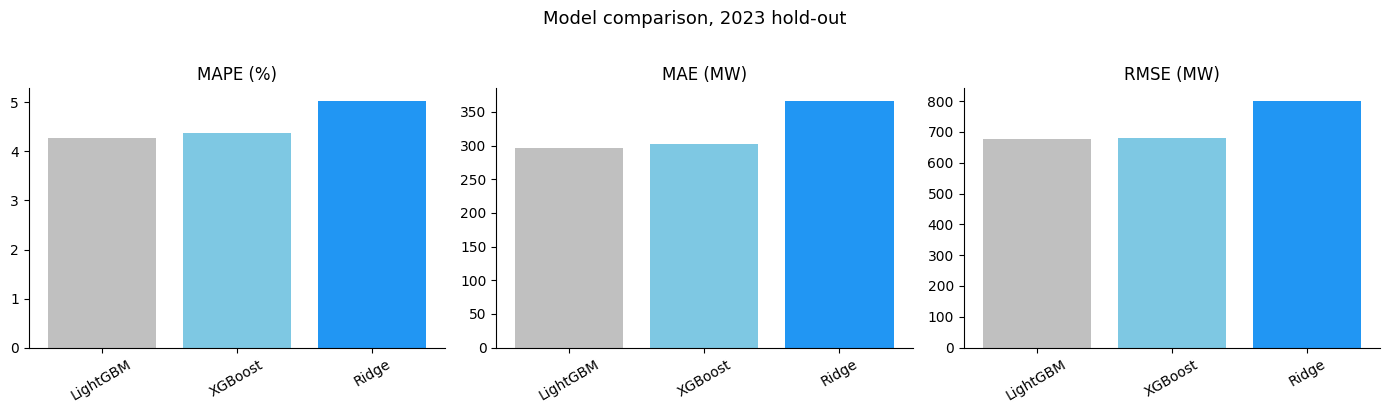

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#c0c0c0", "#7ec8e3", "#2196f3", "#0d47a1"][:len(results_df)]

for i, col in enumerate(["MAPE (%)", "MAE (MW)", "RMSE (MW)"]):
    axes[i].bar(results_df.index, results_df[col], color=colors)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].set_xlabel("")

plt.suptitle("Model comparison, 2023 hold-out", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 15. Hyperparameter tuning

In [61]:
param_grid = {
    "num_leaves":        [31, 64, 128, 255],
    "learning_rate":     [0.01, 0.03, 0.05, 0.08],
    "min_child_samples": [10, 20, 40],
    "subsample":         [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":  [0.6, 0.7, 0.8, 0.9],
    "reg_alpha":         [0.0, 0.05, 0.1, 0.5],
    "reg_lambda":        [0.0, 0.1, 0.5, 1.0],
}

N_TRIALS = 30
trials = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=SEED))

best_mape = np.inf
best_params = None
best_iter_tuned = None
tuning_log = []

print(f"running {N_TRIALS} random trials on LightGBM")

for i, params in enumerate(trials, 1):
    m = lgb.LGBMRegressor(
        n_estimators=1500,
        **params,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(0)],
    )
    va_mape = mape(y_va, m.predict(X_va))
    tuning_log.append({"trial": i, "val_mape": va_mape, **params})

    if va_mape < best_mape:
        best_mape = va_mape
        best_params = params
        best_iter_tuned = m.best_iteration_ or 1000

    if i % 10 == 0:
        print(f"  trial {i:3d}/{N_TRIALS}  best val MAPE: {best_mape:.4f}%")

print(f"\nbest val MAPE: {best_mape:.4f}%")
for k, v in best_params.items():
    print(f"  {k}: {v}")


running 30 random trials on LightGBM
  trial  10/30  best val MAPE: 3.0607%
  trial  20/30  best val MAPE: 3.0607%
  trial  30/30  best val MAPE: 3.0607%

best val MAPE: 3.0607%
  subsample: 0.7
  reg_lambda: 0.1
  reg_alpha: 0.05
  num_leaves: 31
  min_child_samples: 40
  learning_rate: 0.05
  colsample_bytree: 0.9


In [62]:
tuning_df = pd.DataFrame(tuning_log).sort_values("val_mape")
tuning_df.head(10)


,trial,val_mape,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,learning_rate,colsample_bytree
5,6,3.060680,0.7,0.1,0.05,31,40,0.05,0.9
22,23,3.079059,0.7,0.1,0.05,31,20,0.01,0.8
25,26,3.112185,0.8,0.5,0.50,31,20,0.01,0.7
13,14,3.204854,1.0,0.1,0.10,64,20,0.05,0.9
27,28,3.209404,0.7,0.5,0.05,64,20,0.05,0.9
12,13,3.241201,1.0,0.0,0.10,64,40,0.05,0.9
0,1,3.242592,0.9,0.1,0.10,64,20,0.03,0.8
4,5,3.248066,0.7,1.0,0.50,128,20,0.08,0.9
17,18,3.263551,1.0,0.1,0.05,64,40,0.03,0.9
29,30,3.288003,0.9,0.5,0.50,31,10,0.01,0.9


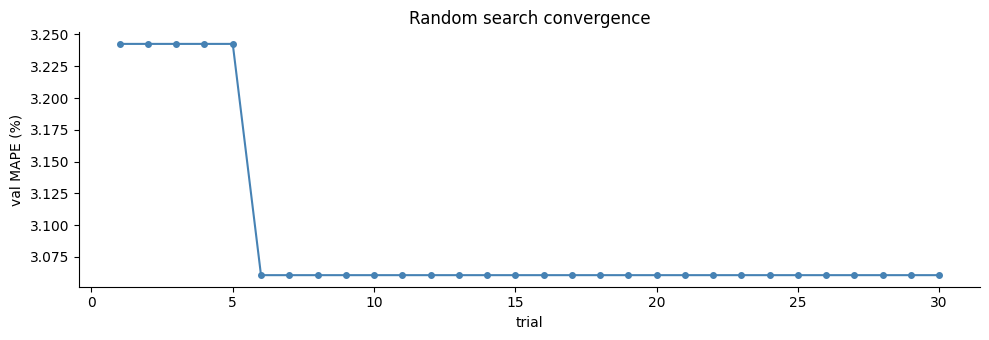

In [63]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ordered = tuning_df.sort_values("trial")
ax.plot(ordered["trial"], ordered["val_mape"].cummin(),
        marker="o", ms=4, lw=1.5, color="steelblue")
ax.set_xlabel("trial")
ax.set_ylabel("val MAPE (%)")
ax.set_title("Random search convergence")
plt.tight_layout()
plt.show()


## 16. Final model

In [64]:
final_model = lgb.LGBMRegressor(
    n_estimators=best_iter_tuned,
    **best_params,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)
final_result = evaluate("LightGBM (tuned)", y_test, final_pred)

base_mape = (
    results_df.loc["LightGBM", "MAPE (%)"]
    if "LightGBM" in results_df.index
    else results_df["MAPE (%)"].min()
)
print(f"\ntuned vs base:  {base_mape:.3f}%  ->  {final_result['MAPE (%)']:.3f}%")


LightGBM (tuned)                MAPE= 4.052%   MAE=  265.3 MW   RMSE=  660.6 MW

tuned vs base:  4.283%  ->  4.052%


## 17. Diagnostics

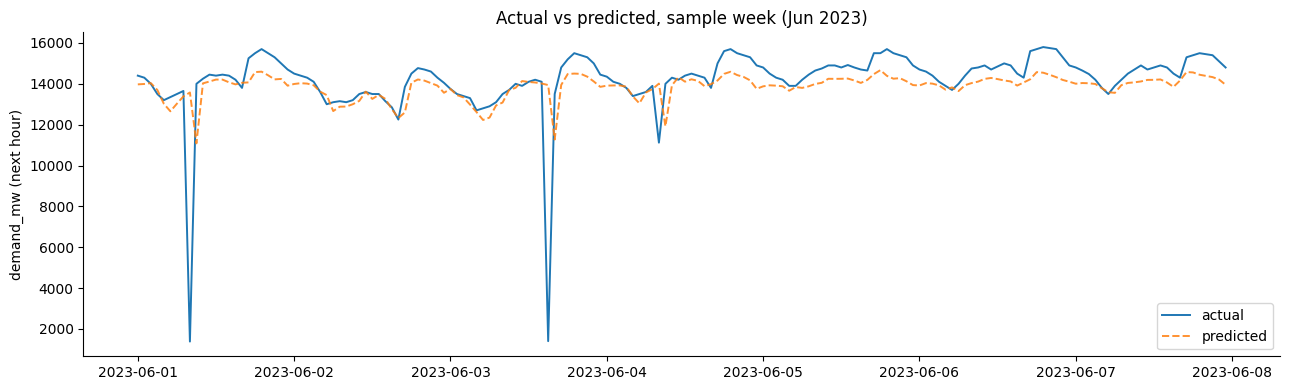

In [65]:
sample_mask = test_mask & (fe["datetime"] >= "2023-06-01") & (fe["datetime"] < "2023-06-08")
ts = fe.loc[sample_mask, "datetime"]
yt = fe.loc[sample_mask, "target"]
yp = final_model.predict(fe.loc[sample_mask, feature_cols])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts, yt, label="actual", lw=1.4)
ax.plot(ts, yp, label="predicted", lw=1.4, alpha=0.85, linestyle="--")
ax.set_title("Actual vs predicted, sample week (Jun 2023)")
ax.set_ylabel("demand_mw (next hour)")
ax.legend()
plt.tight_layout()
plt.show()


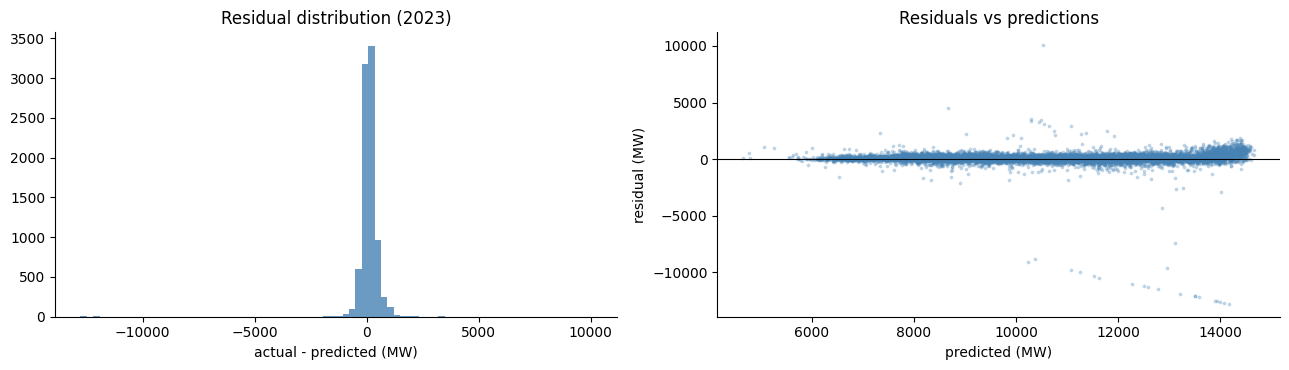

In [66]:
resid = y_test.values - final_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(resid, bins=80, color="steelblue", alpha=0.8)
axes[0].set_title("Residual distribution (2023)")
axes[0].set_xlabel("actual - predicted (MW)")

axes[1].scatter(final_pred, resid, s=3, alpha=0.25, color="steelblue")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("predicted (MW)")
axes[1].set_ylabel("residual (MW)")
axes[1].set_title("Residuals vs predictions")

plt.tight_layout()
plt.show()


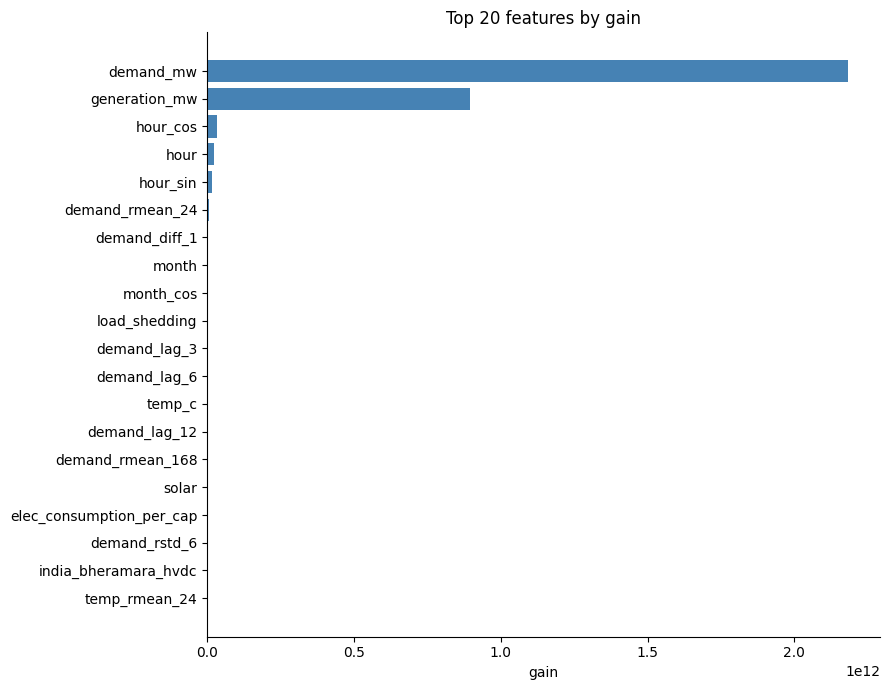

,feature,gain,split
0,demand_mw,2.182610e+12,673
1,generation_mw,8.942906e+11,460
38,hour_cos,3.365973e+10,729
32,hour,2.278098e+10,1198
37,hour_sin,1.668023e+10,825
54,demand_rmean_24,5.339008e+09,241
58,demand_diff_1,4.195766e+09,549
35,month,3.491712e+09,330
40,month_cos,2.992218e+09,357
2,load_shedding,2.977647e+09,256


In [67]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "gain":    final_model.booster_.feature_importance(importance_type="gain"),
    "split":   final_model.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)

top = imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["feature"], top["gain"], color="steelblue")
ax.set_xlabel("gain")
ax.set_title("Top 20 features by gain")
plt.tight_layout()
plt.show()

imp.head(25)


## 18. Export

In [68]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

output = fe.loc[test_mask, ["datetime", "demand_mw"]].copy().reset_index(drop=True)
output["predicted_demand_mw_next_hour"] = final_pred
output["abs_error_mw"] = np.abs(output["demand_mw"] - output["predicted_demand_mw_next_hour"])
output["pct_error"]    = (output["abs_error_mw"] / output["demand_mw"] * 100).round(3)

out_path = OUT_DIR / "predictions_2023.csv"
output.to_csv(out_path, index=False)
print(f"saved {len(output):,} rows -> {out_path.name}")
output.head(10)


saved 8,760 rows -> predictions_2023.csv


,datetime,demand_mw,predicted_demand_mw_next_hour,abs_error_mw,pct_error
0,2023-01-01 00:00:00,6921.0,6553.232499,367.767501,5.314
1,2023-01-01 01:00:00,6544.0,6291.633435,252.366565,3.856
2,2023-01-01 02:00:00,6258.0,6113.791170,144.208830,2.304
3,2023-01-01 03:00:00,5998.0,5961.625490,36.374510,0.606
4,2023-01-01 04:00:00,5988.0,6164.128435,176.128435,2.941
5,2023-01-01 05:00:00,6331.0,6796.777719,465.777719,7.357
6,2023-01-01 06:00:00,6678.0,7370.971686,692.971686,10.377
7,2023-01-01 07:00:00,7326.0,7742.802166,416.802166,5.689
8,2023-01-01 08:00:00,7813.0,7899.125906,86.125906,1.102
9,2023-01-01 09:00:00,7733.0,7897.966910,164.966910,2.133


In [69]:
check = pd.read_csv(OUT_DIR / "predictions_2023.csv")
print("shape:", check.shape)
print("columns:", list(check.columns))
print("MAPE from csv:", round(mape(check["demand_mw"], check["predicted_demand_mw_next_hour"]), 3), "%")


shape: (8760, 5)
columns: ['datetime', 'demand_mw', 'predicted_demand_mw_next_hour', 'abs_error_mw', 'pct_error']
MAPE from csv: 4.479 %
